Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')
Cột trong dữ liệu:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Kiểu dữ liệu:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337


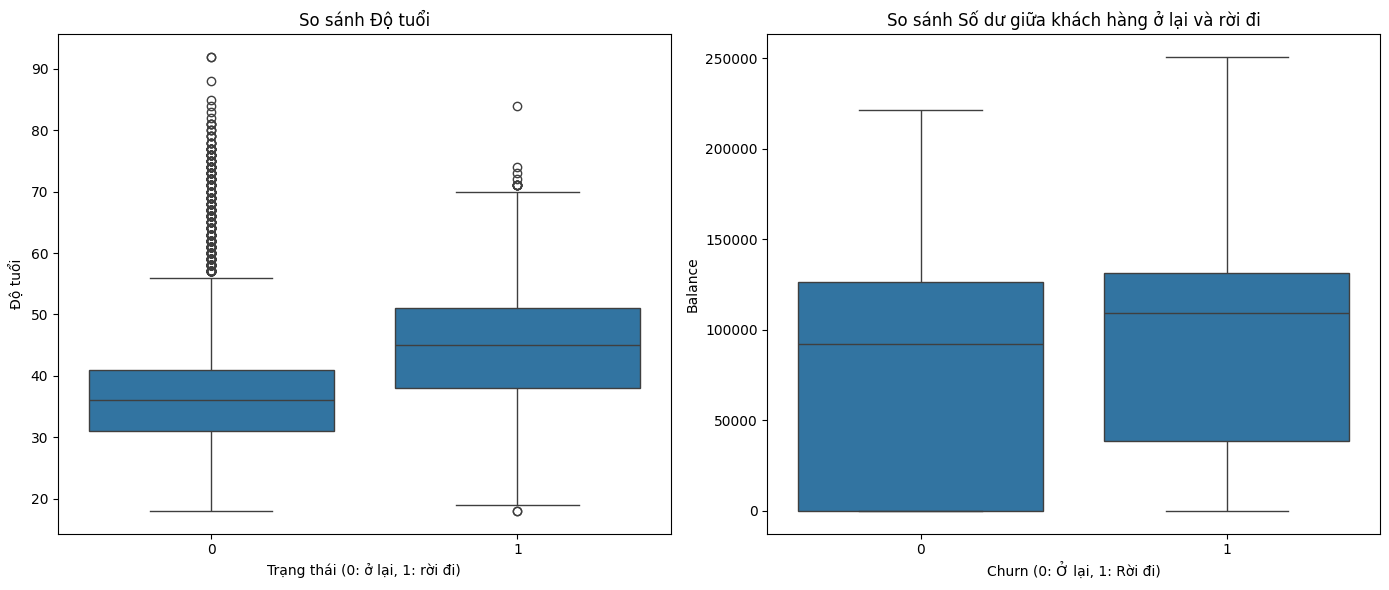

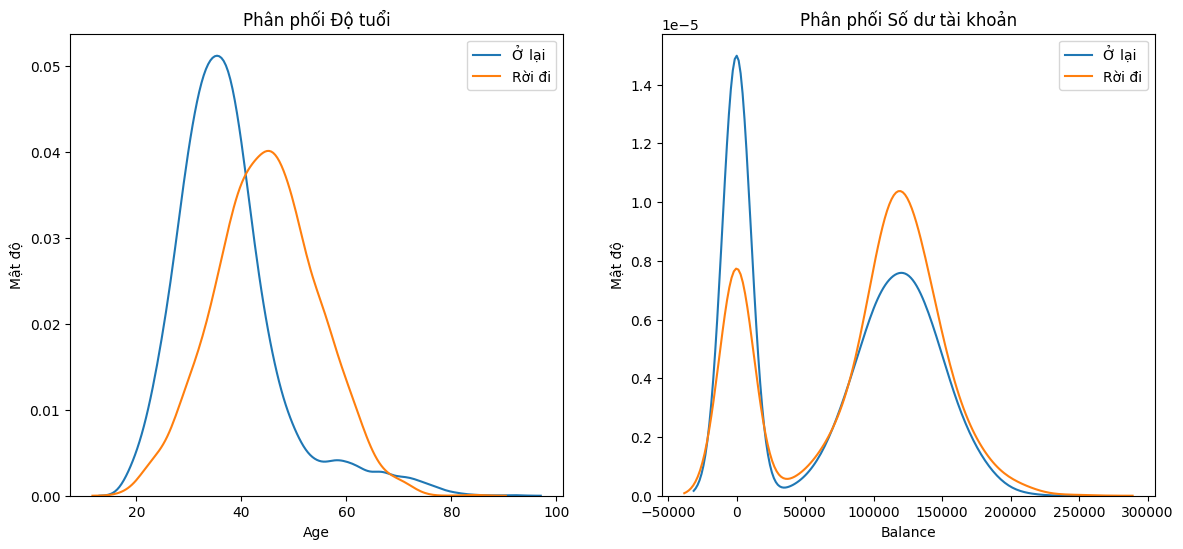

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

# Fix tên cột
df.columns = df.columns.str.strip()

# Kiểm tra nhanh
print(df.columns)
# Thống kê
print("Cột trong dữ liệu:")
print(df.columns)

print("\nKiểu dữ liệu:")
print(df.dtypes)

# Fix khoảng trắng
df.columns = df.columns.str.strip()

# Thử lại
comparison_stats = df.groupby('churn')[['age', 'balance']].mean()
print(comparison_stats)
# Boxplot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='age', data=df)
plt.title('So sánh Độ tuổi')
plt.xlabel('Trạng thái (0: ở lại, 1: rời đi)')
plt.ylabel('Độ tuổi')

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('So sánh Số dư giữa khách hàng ở lại và rời đi')
plt.xlabel('Churn (0: Ở lại, 1: Rời đi)')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

# KDE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(df[df['churn'] == 0]['age'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['age'], label='Rời đi')

plt.title('Phân phối Độ tuổi')
plt.xlabel('Age')
plt.ylabel('Mật độ')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['churn'] == 0]['balance'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['balance'], label='Rời đi')

plt.title('Phân phối Số dư tài khoản')
plt.xlabel('Balance')
plt.ylabel('Mật độ')
plt.legend()

plt.show()



=== GIÁ TRỊ TRUNG BÌNH ===
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337

=== PHƯƠNG SAI ===
              age       balance
churn                          
0      102.522974  3.949876e+09
1       95.288084  3.405982e+09


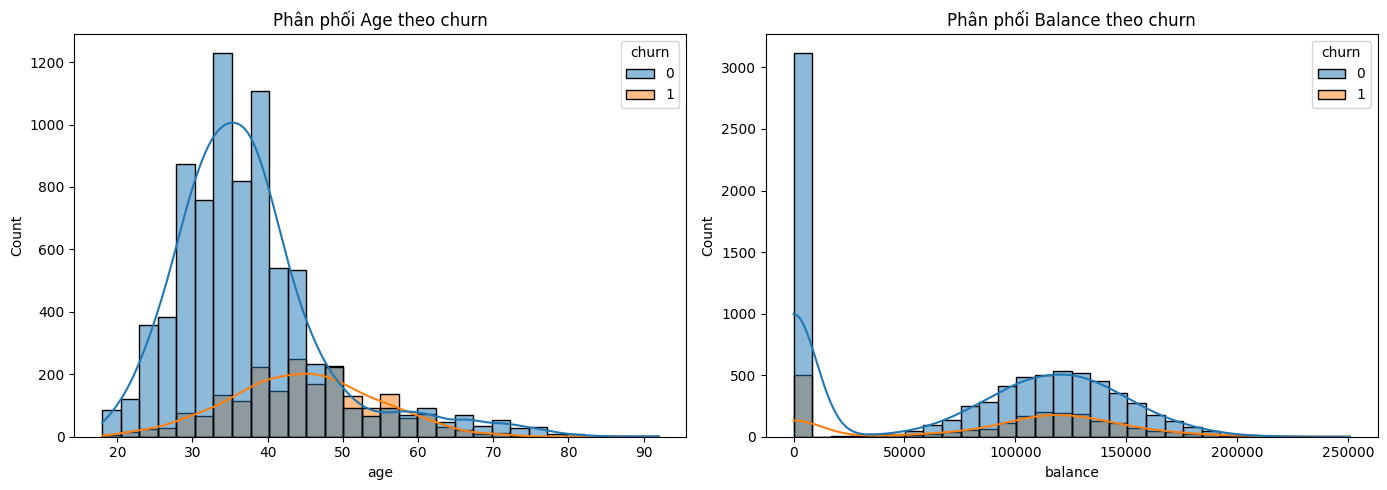

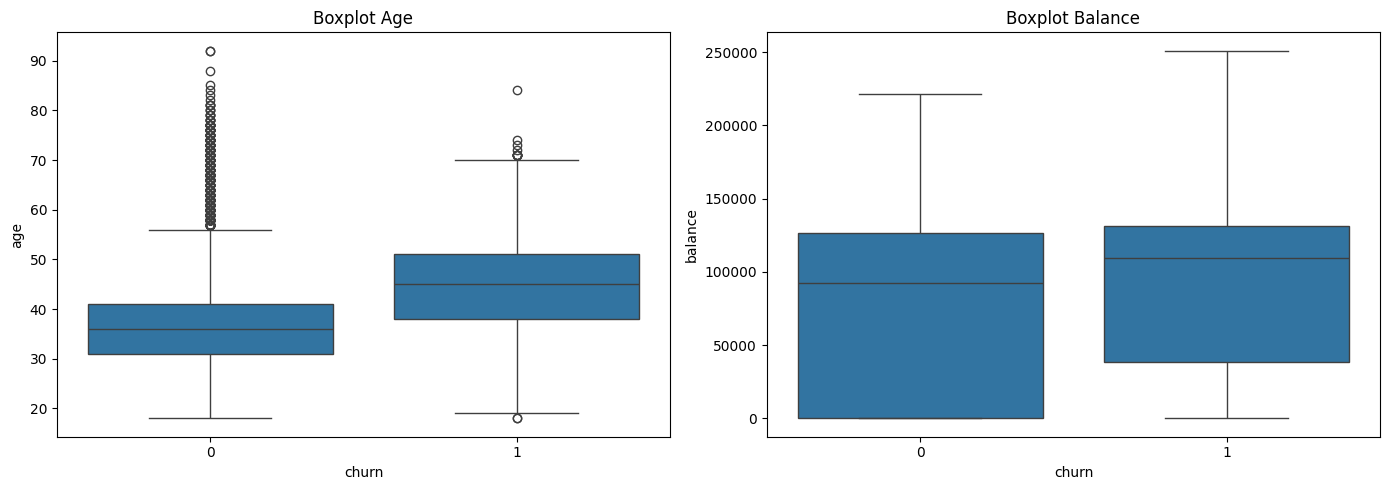

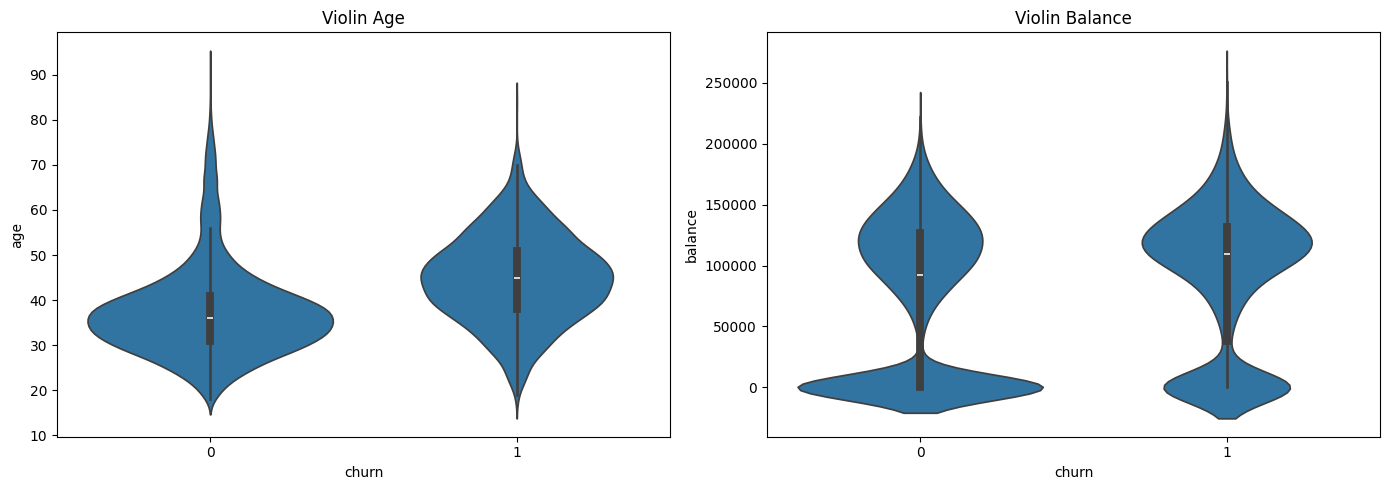

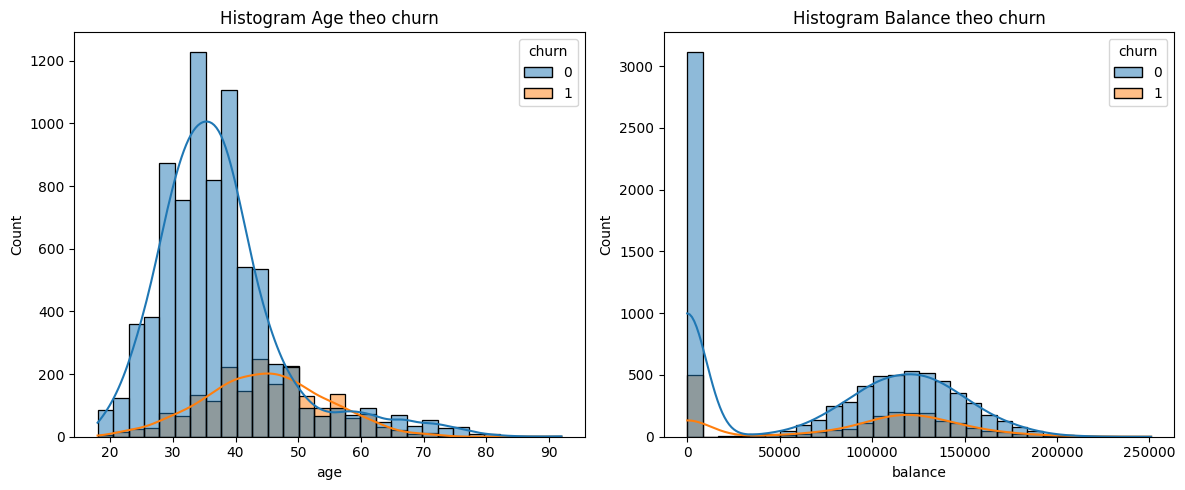


=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===

Biến: credit_score
Ở lại (0): 651.85
Rời đi (1): 645.35
→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn

Biến: age
Ở lại (0): 37.41
Rời đi (1): 44.84
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn

Biến: balance
Ở lại (0): 72745.30
Rời đi (1): 91108.54
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn

=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===

--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---
credit_score      651.853196
age                37.408389
balance         72745.296779
dtype: float64

--- SO SÁNH VỚI NHÓM RỜI BỎ ---

Biến: credit_score
Chuẩn (0): 651.85
Rời bỏ (1): 645.35
Chênh lệch: -6.50
→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn

Biến: age
Chuẩn (0): 37.41
Rời bỏ (1): 44.84
Chênh lệch: 7.43
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn

Biến: balance
Chuẩn (0): 72745.30
Rời bỏ (1): 91108.54
Chênh lệch: 18363.24
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn


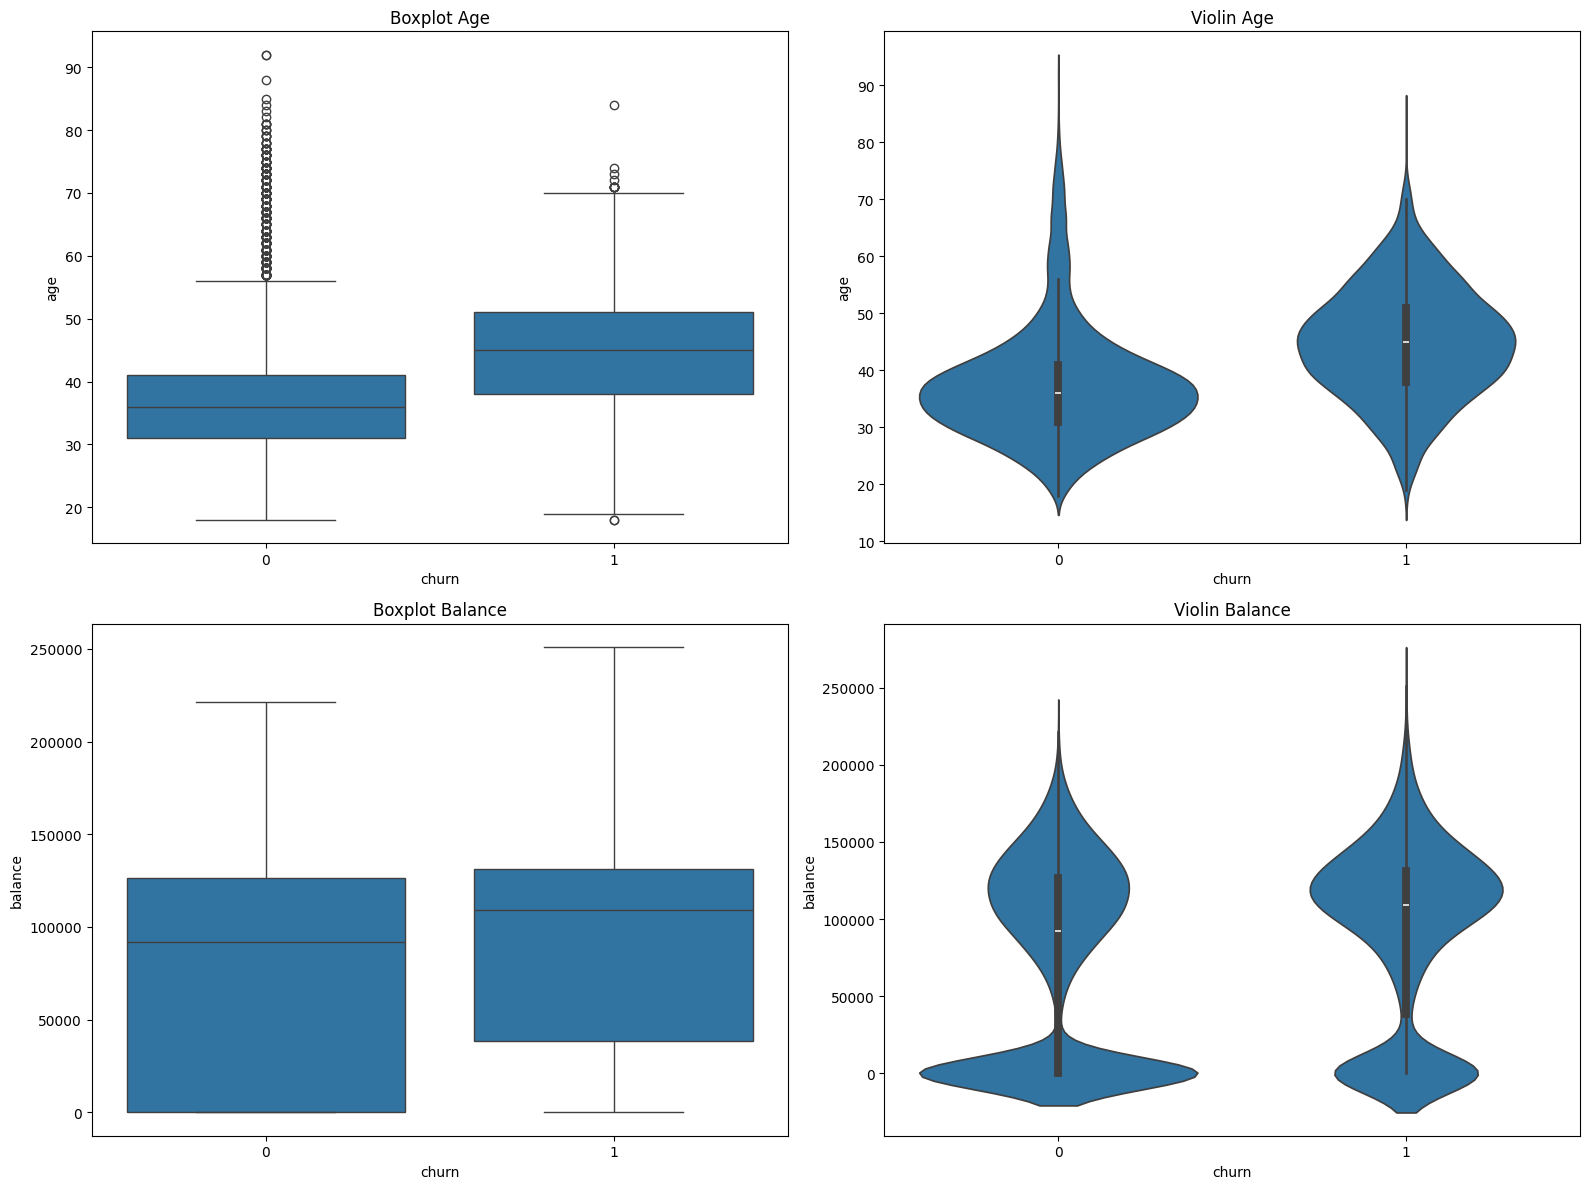

In [20]:
import pandas as pd                     
import seaborn as sns
import matplotlib.pyplot as plt                                 #pandas (pd) → xử lý dữ liệu dạng bảng (DataFrame)
                                                                #seaborn (sns) → vẽ biểu đồ thống kê đẹp, dễ dùng
                                                                # matplotlib.pyplot (plt) → thư viện nền để vẽ biểu đồ

# ==============================
# 1. Đọc dữ liệu
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')                                  #Đọc file CSV vào DataFrame df
                                                                                            # Mỗi dòng → 1 khách hàng
                                                                                            # Mỗi cột → thông tin (age, balance, churn,...)

# ==============================
# 2. So sánh giá trị trung bình
# ==============================
print("=== GIÁ TRỊ TRUNG BÌNH ===")
mean_values = df.groupby('churn')[['age', 'balance']].mean()
print(mean_values)                                                          
                                                                                            # groupby('churn') → chia dữ liệu thành 2 nhóm:
                                                                                            # churn = 0 → khách ở lại
                                                                                            # churn = 1 → khách rời đi
                                                                                            # [['age', 'balance']] → chỉ lấy 2 cột cần phân tích
                                                                                            # .mean() → tính trung bình

# ==============================
# 3. So sánh phương sai
# ==============================
print("\n=== PHƯƠNG SAI ===")
var_values = df.groupby('churn')[['age', 'balance']].var()
print(var_values)
                                                                                            # .var() → phương sai (mức độ phân tán)
                                                                                            # Ý nghĩa:

                                                                                            # Giá trị lớn → dữ liệu phân tán mạnh
                                                                                            # Giá trị nhỏ → dữ liệu tập trung
                                                                                            # Age churn=1 có var lớn → độ tuổi khách rời đi rất đa dạng
# Nếu dataset dùng 'Exited' thì đổi tên
if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)
                                                                                            # Vì dataset có thể dùng:

                                                                                            # Exited (chuẩn Kaggle)
                                                                                            # hoặc churn

                                                                                            # Nếu có Exited → đổi thành churn cho đồng nhất

# ==============================
# Histogram (so sánh phân phối tổng quan)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Phân phối Age theo churn')
                                                                                            # x='age' → vẽ theo tuổi
                                                                                            # hue='churn' → tách màu theo churn (0 và 1)
                                                                                            # bins=30 → chia 30 khoảng
                                                                                            # kde=True → thêm đường mật độ

                                                                                        #GT
                                                                                            # Xem phân phối tuổi giữa 2 nhóm
                                                                                            # Nhìn được:
                                                                                            # lệch trái/phải
                                                                                            # tập trung ở đâu

# Balance
plt.subplot(1,2,2)                                                                          #Chia khung vẽ:
                                                                                            # 1 hàng, 2 cột
                                                                                            # biểu đồ thứ 1
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Phân phối Balance theo churn')

plt.tight_layout()                                                                           #sửa căn chỉnh kcach cho cân đối
plt.show()

# ==============================
# Boxplot (so sánh median + outlier)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.boxplot(x='churn', y='age', data=df)                
plt.title('Boxplot Age')
                                                                                                                            # Hiển thị:

                                                                                                                            # Median (đường giữa)
                                                                                                                            # Q1, Q3 (hộp)
                                                                                                                            # Outlier (điểm lẻ)

                                                                                                                            #  Ý nghĩa:

                                                                                                                            # So sánh nhanh:
                                                                                                                            # tuổi trung vị
                                                                                                                            # độ phân tán
                                                                                                                            # ngoại lệ

                                                                                                                            #  Ví dụ:

                                                                                                                            # churn=1 có median cao → người lớn tuổi dễ rời đi

# Balance
plt.subplot(1,2,2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Boxplot Balance')

plt.tight_layout()
plt.show()

# ==============================
#  Violin plot (so sánh mật độ phân phối)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.violinplot(x='churn', y='age', data=df)
plt.title('Violin Age')

# Balance
plt.subplot(1,2,2)
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Violin Balance')

plt.tight_layout()
plt.show()
# ==============================
# 4. Histogram (theo churn)
# ==============================
plt.figure(figsize=(12,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Histogram Age theo churn')

# Balance
plt.subplot(1,2,2)
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Histogram Balance theo churn')

plt.tight_layout()
plt.show()

# ==============================
# 5. Boxplot + Violin (4 biểu đồ)
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# AGE
sns.boxplot(data=df, x='churn', y='age', ax=axes[0,0])
axes[0,0].set_title('Boxplot Age')

sns.violinplot(data=df, x='churn', y='age', ax=axes[0,1])
axes[0,1].set_title('Violin Age')

# BALANCE
sns.boxplot(data=df, x='churn', y='balance', ax=axes[1,0])
axes[1,0].set_title('Boxplot Balance')

sns.violinplot(data=df, x='churn', y='balance', ax=axes[1,1])
axes[1,1].set_title('Violin Balance')
# ==============================
#6 Phân tích nguyên nhân churn
# ==============================
print("\n=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===")

features = ['credit_score','age','balance']

for col in features:
    mean_0 = df[df['churn'] == 0][col].mean()
    mean_1 = df[df['churn'] == 1][col].mean()
    
    print(f"\nBiến: {col}")
    print(f"Ở lại (0): {mean_0:.2f}")
    print(f"Rời đi (1): {mean_1:.2f}")
    
    if mean_1 > mean_0:
        print("→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn")
    else:
        print("→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn")
        
    
        # ==============================
#7 PHÂN TÍCH DỰA TRÊN CHURN = 0 (BASELINE)
# ==============================
print("\n=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===")

features = ['credit_score','age','balance']

# Trung bình nhóm chuẩn (churn = 0)
baseline = df[df['churn'] == 0][features].mean()

print("\n--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---")
print(baseline)

# So sánh với churn = 1
print("\n--- SO SÁNH VỚI NHÓM RỜI BỎ ---")

for col in features:
    base = baseline[col]
    churn1 = df[df['churn'] == 1][col].mean()
    
    diff = churn1 - base
    
    print(f"\nBiến: {col}")
    print(f"Chuẩn (0): {base:.2f}")
    print(f"Rời bỏ (1): {churn1:.2f}")
    print(f"Chênh lệch: {diff:.2f}")
    
    # Phân tích theo hướng lệch
    if diff > 0:
        print("→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn")
    else:
        print("→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn")

plt.tight_layout()
plt.show()

In [21]:
# NHẬN XÉT TRỰC QUAN HÓA SO SÁNH (CHURN VS NON-CHURN)
# Ý tưởng:

# Sử dụng kết hợp Boxplot và Violin Plot để so sánh sự khác biệt giữa hai nhóm khách hàng:

# Nhóm ở lại (churn = 0)
# Nhóm rời đi (churn = 1)
# Các biến được phân tích:

# age
# balance
# Mục đích:

# Xác định sự khác biệt về hành vi giữa 2 nhóm
# Tìm ra yếu tố ảnh hưởng đến việc rời bỏ dịch vụ
# Phương pháp trực quan hóa
# Boxplot
# So sánh:

# Trung vị (median)

# Độ phân tán

# Outliers

# Giúp thấy rõ sự khác biệt tổng quan

# Violin Plot

# Hiển thị:

# Phân phối dữ liệu (density)
# Hình dạng phân bố
# Giúp hiểu sâu hơn về cấu trúc dữ liệu
# Kết quả phân tích:

# Age (Độ tuổi)
# Nhóm churn = 1 (rời đi):

# Có xu hướng lớn tuổi hơn
# Median cao hơn rõ rệt

# Nhóm churn = 0 (ở lại):
# Tập trung ở nhóm tuổi trẻ hơn
# Violin plot cho thấy:

# Phân phối của nhóm rời đi lệch về phía tuổi cao
# Kết luận:

# Khách hàng lớn tuổi có xu hướng rời bỏ dịch vụ cao hơn
# Balance (Số dư tài khoản)
# Nhóm churn = 1:

# Có xu hướng có số dư cao hơn
# Phân phối rộng hơn
# Nhóm churn = 0:

# Nhiều khách có balance = 0
# Violin plot thể hiện:

# Hai đỉnh rõ rệt (bimodal)
# Nhóm churn tập trung nhiều ở vùng số dư cao
# Kết luận:

# Khách hàng có số dư lớn có khả năng rời đi cao hơn (có thể do tìm dịch vụ tốt hơn)
# Tổng kết chung:

# Age và Balance đều có sự khác biệt rõ giữa 2 nhóm
# Đây là 2 biến quan trọng trong việc:

# Phân tích churn
# Xây dựng mô hình dự đoán
# Sự khác biệt rõ rệt trong phân phối của hai biến age và balance giữa hai nhóm churn và non-churn cho thấy đây là những biến có khả năng phân tách tốt (good discriminative features) trong bài toán dự đoán khách hàng rời bỏ.

In [22]:
mean_values = df.groupby('churn')[['age', 'balance']].mean()
var_values = df.groupby('churn')[['age', 'balance']].var()

In [23]:
mean_values = df.groupby('churn')[['credit_score','age', 'balance']].mean()
var_values = df.groupby('churn')[['credit_score','age', 'balance']].var()

Ellipsis

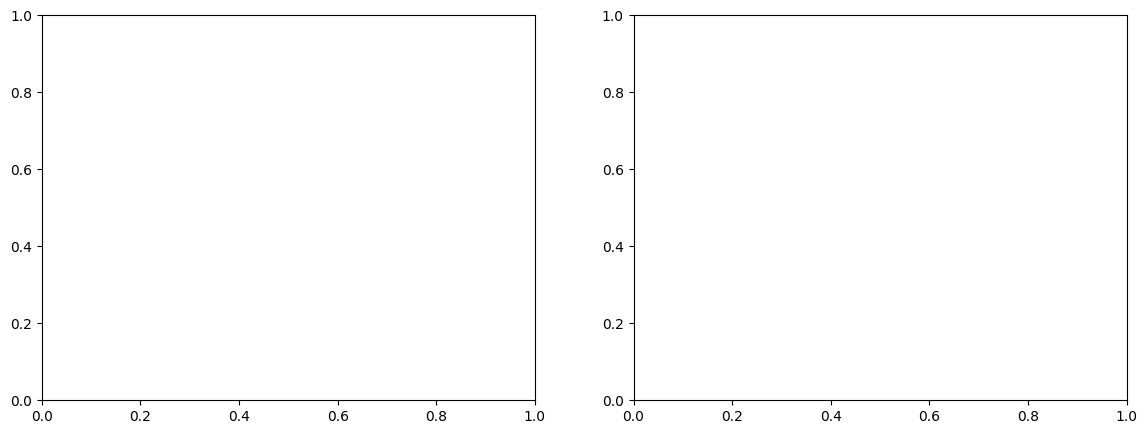

In [24]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
...
plt.subplot(1,2,2)
...

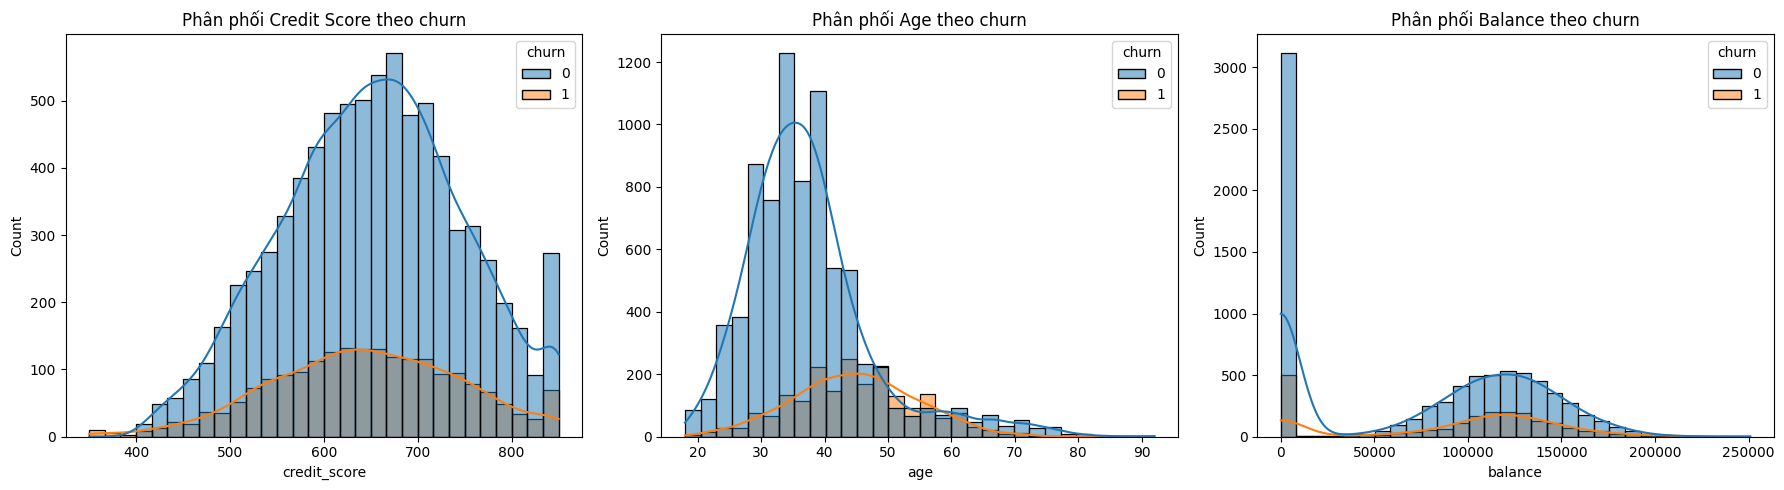

In [25]:
plt.figure(figsize=(18,5))

# Credit Score
plt.subplot(1,3,1)
sns.histplot(data=df, x='credit_score', hue='churn', bins=30, kde=True)
plt.title('Phân phối Credit Score theo churn')

# Age
plt.subplot(1,3,2)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Phân phối Age theo churn')

# Balance
plt.subplot(1,3,3)
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Phân phối Balance theo churn')

plt.tight_layout()
plt.show()

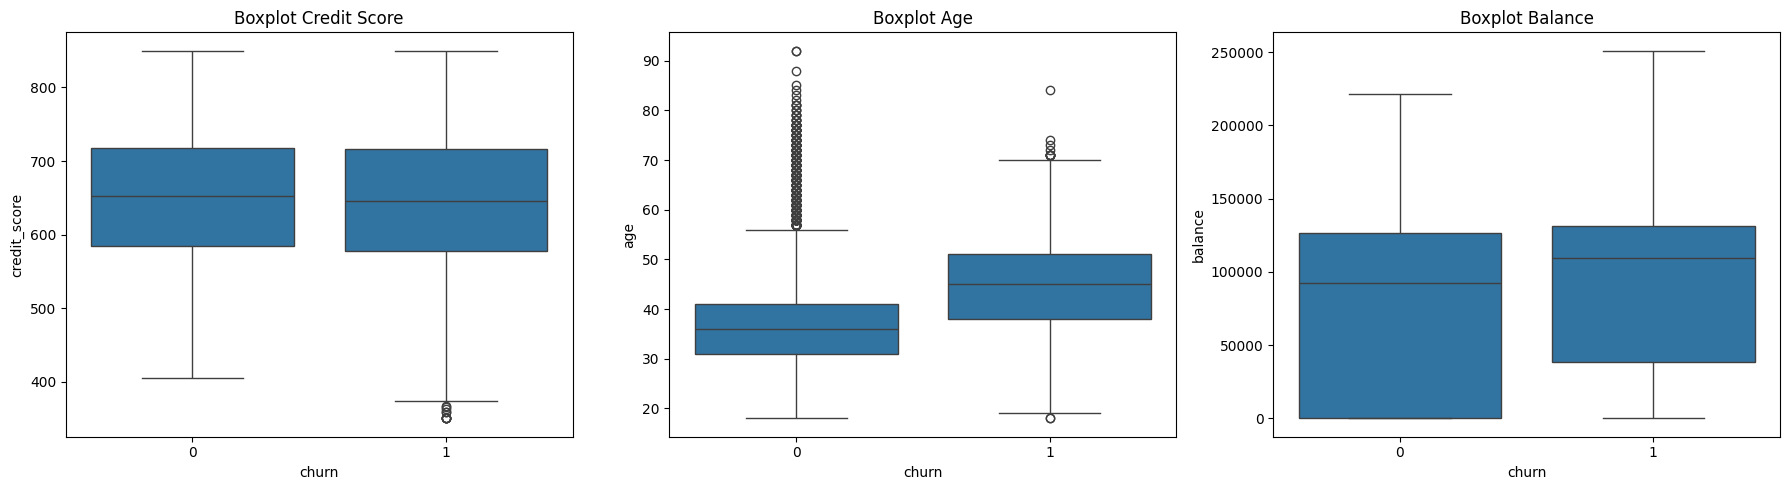

In [26]:
plt.figure(figsize=(18,5))

# Credit Score
plt.subplot(1,3,1)
sns.boxplot(x='churn', y='credit_score', data=df)
plt.title('Boxplot Credit Score')

# Age
plt.subplot(1,3,2)
sns.boxplot(x='churn', y='age', data=df)
plt.title('Boxplot Age')

# Balance
plt.subplot(1,3,3)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Boxplot Balance')

plt.tight_layout()
plt.show()


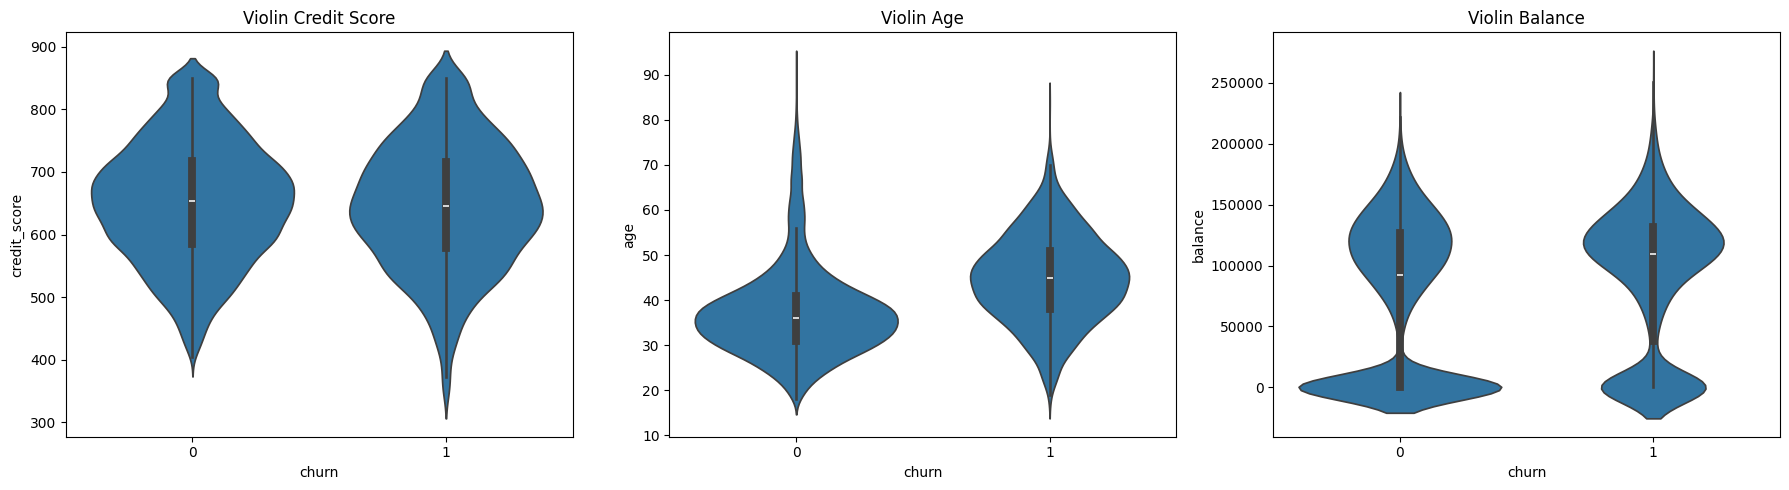

In [27]:
plt.figure(figsize=(18,5))

# Credit Score
plt.subplot(1,3,1)
sns.violinplot(x='churn', y='credit_score', data=df)
plt.title('Violin Credit Score')

# Age
plt.subplot(1,3,2)
sns.violinplot(x='churn', y='age', data=df)
plt.title('Violin Age')

# Balance
plt.subplot(1,3,3)
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Violin Balance')

plt.tight_layout()
plt.show()

In [28]:
# ==============================
# Phân tích nguyên nhân churn
# ==============================
print("\n=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===")

features = ['credit_score','age','balance']

for col in features:
    mean_0 = df[df['churn'] == 0][col].mean()
    mean_1 = df[df['churn'] == 1][col].mean()
    
    print(f"\nBiến: {col}")
    print(f"Ở lại (0): {mean_0:.2f}")
    print(f"Rời đi (1): {mean_1:.2f}")
    
    if mean_1 > mean_0:
        print("→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn")
    else:
        print("→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn")


=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===

Biến: credit_score
Ở lại (0): 651.85
Rời đi (1): 645.35
→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn

Biến: age
Ở lại (0): 37.41
Rời đi (1): 44.84
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn

Biến: balance
Ở lại (0): 72745.30
Rời đi (1): 91108.54
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn


In [29]:
# ==============================
# PHÂN TÍCH DỰA TRÊN CHURN = 0 (BASELINE)
# ==============================
print("\n=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===")

features = ['credit_score','age','balance']

# Trung bình nhóm chuẩn (churn = 0)
baseline = df[df['churn'] == 0][features].mean()

print("\n--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---")
print(baseline)

# So sánh với churn = 1
print("\n--- SO SÁNH VỚI NHÓM RỜI BỎ ---")

for col in features:
    base = baseline[col]
    churn1 = df[df['churn'] == 1][col].mean()
    
    diff = churn1 - base
    
    print(f"\nBiến: {col}")
    print(f"Chuẩn (0): {base:.2f}")
    print(f"Rời bỏ (1): {churn1:.2f}")
    print(f"Chênh lệch: {diff:.2f}")
    
    # Phân tích theo hướng lệch
    if diff > 0:
        print("→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn")
    else:
        print("→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn")


=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===

--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---
credit_score      651.853196
age                37.408389
balance         72745.296779
dtype: float64

--- SO SÁNH VỚI NHÓM RỜI BỎ ---

Biến: credit_score
Chuẩn (0): 651.85
Rời bỏ (1): 645.35
Chênh lệch: -6.50
→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn

Biến: age
Chuẩn (0): 37.41
Rời bỏ (1): 44.84
Chênh lệch: 7.43
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn

Biến: balance
Chuẩn (0): 72745.30
Rời bỏ (1): 91108.54
Chênh lệch: 18363.24
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn
